# MLS211 Task 1B Data Analysis

## Usage

Select all the data from the table in the student's report as shown below. Copy and paste the data into the input text for each section of this notebook, replacing the existing sample data.
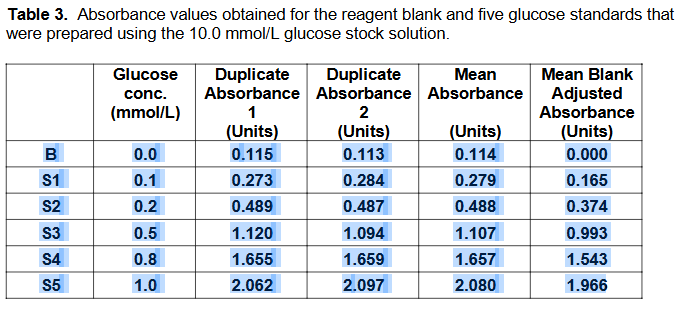

Then run each cell in sequence to perform the necessary calculations

## Initialise notebook

In [ ]:
# Import all necessary libraries
import pathlib
from decimal import ROUND_HALF_UP, Decimal
from io import StringIO

import matplotlib.pyplot as plt
import numpy as np
import openpyxl
import pandas as pd

DEFAULT_INPUT_FILE = "./Task 1a/task1atable3.txt"
DEFAULT_EXCEL_FILE = "./Task 1a/Task 1a.xlsx"

class ExcelWriter:
    """A class to write data to an Excel file."""

    def __init__(self):
        pass

    def write_dataframe_to_excel(self, df: pd.DataFrame, output_path: pathlib.Path, sheet_name:str, col_offset:int=0, row_offset:int=0) -> None:
        """Write a 2D list of data to an Excel file."""
        if output_path.exists():
            workbook = openpyxl.load_workbook(output_path)
        else:
            raise FileNotFoundError(f"Excel file not found: {output_path.resolve()}")
        sheet = workbook[sheet_name]

        for row in range(df.shape[0]):
            for col in range(df.shape[1]):
                value = df.iloc[row, col]
                sheet.cell(row=row + row_offset, column=col + col_offset, value=value)

        workbook.save(output_path)

class StandardCurveBuilder:
    """Build the standard curve from the aborbances and known values"""
    def __init__(self):
        self.df: pd.DataFrame = None

    def read(self, text:str):
        # Use StringIO to treat the string as a file-like object
        data = StringIO(text)
        self.df = pd.read_csv(data, sep=" ", header=None)
        return self

    def set_colnames(self, colnames: list[str]):
        if not len(colnames) == self.df.shape[1]:
            raise ValueError(f"Expected {len(colnames)} columns but data contains {self.df.shape[1]}.")
        else:
            self.df.columns = colnames
        return self

    def calc_abs_means(self, absorbance_cols: list[str]):
        self.df["Mean_Abs"] = self.df.loc[:, absorbance_cols].mean(axis=1)
        self.df["Blanked_Abs"] = self.df['Mean_Abs'] - self.df['Mean_Abs'].iloc[0]
        return self

    def build(self) -> pd.DataFrame:
        return self.df

class StandardCurveAnalyser:
    """A class to analyze standard curves from pandas dataframe."""
    def __init__(self, df: pd.DataFrame):
        self.df = df
        self.slope = 0

    def linear_regression(self, std_col: str, abs_col:str) -> tuple[float, float]:
        x = self.df.loc[:, std_col].array
        y = self.df.loc[:, abs_col].array
        if len(x) != len(y):
            raise ValueError("x and y must have the same length.")
        # Reshape to a column matix for the least squares calculation
        X = x[:, np.newaxis]
        # Calculate the slope (m), forcing the intercept to be 0
        slope, _residuals, _rank, _s = np.linalg.lstsq(X, y, rcond=None)
        self.slope = slope[0]
        return (slope[0], 0)  # Return slope and intercept (0)

    def r_squared_forced_through_origin(self, std_col: str, abs_col:str) -> float:
        """Calculate R-squared for a linear regression forced through the origin."""
        x = self.df.loc[:, std_col].array
        y = self.df.loc[:, abs_col].array
        if len(x) != len(y):
            raise ValueError("x and y must have the same length.")
        slope, _ = self.linear_regression(std_col, abs_col)
        y_pred = slope * x
        ss_res = np.sum((y - y_pred) ** 2)
        #ss_tot = np.sum((y - np.mean(y)) ** 2)
        ss_tot = np.sum(y ** 2)
        r_squared = 1 - (ss_res / ss_tot)
        return r_squared

    def calculate_sample_concentration(self, df_samples: pd.DataFrame, col_conc: str, col_abs: str, dilution_factor: float) -> pd.DataFrame:
        df_samples[col_abs] = df_samples['Mean_Abs'] - self.df['Mean_Abs'].iloc[0]

        df_samples[col_conc] = df_samples[col_abs].div(self.slope).mul(dilution_factor)
        df_samples[col_conc] = df_samples[col_conc].round(1)
        return df_samples

def round_half_up(data: pd.Series, target_str: str) -> pd.Series:
    target = Decimal(target_str)
    data = data.apply(
        lambda x: Decimal(str(x)).quantize(target, rounding=ROUND_HALF_UP)
    )
    return data


## Table 1: Glucose

In [ ]:
# S_Mean is the mean value submitted by the student
# S_Blanked is the blanked value submitted by the student
colnames = ["ID","Conc","Abs1", "Abs2", "S_Mean", "S_Blanked"]

sample_dilution_factor = 16.01

# Absorbances for standard curve
std_data = """
RB 0.0 0.086 0.091 0.089 0.000
S1 0.1 0.286 0.302 0.294 0.206
S2 0.2 0.487 0.486 0.487 0.398
S3 0.5 1.062 1.083 1.073 0.984
S4 0.8 1.690 1.704 1.697 1.609
S5 1.0 2.091 2.146 2.119 2.030
"""

sample_data = """
P1-F Unknown 0.805 0.820 0.813 0.724
P1-60 Unknown 1.776 1.812 1.794 1.705
P1-120 Unknown 1.224 1.297 1.261 1.172
P2-F Unknown 1.019 1.036 1.028 0.939
P2-120 Unknown 1.539 1.527 1.533 1.444
QC Unknown 0.836 0.823 0.830 0.741
"""

builder = StandardCurveBuilder()
df = builder.read(std_data.strip()).set_colnames(colnames).calc_abs_means(["Abs1", "Abs2"]).build()
analyser = StandardCurveAnalyser(df)
reg = analyser.linear_regression("Conc","Blanked_Abs")
r_squared = analyser.r_squared_forced_through_origin("Conc", "Blanked_Abs")

df_samples = builder.read(sample_data.strip()).set_colnames(colnames).calc_abs_means(["Abs1", "Abs2"]).build()

df_samples = analyser.calculate_sample_concentration(df_samples,"Conc","Blanked_Abs", sample_dilution_factor)

# Round data prior to printing
df['Mean_Abs'] = round_half_up(df['Mean_Abs'], "0.001")
df['Blanked_Abs'] = round_half_up(df['Blanked_Abs'], "0.001")

x = df["Conc"]
y = df['Blanked_Abs']
trendline = x * reg[0]
# Create scatter chart
# Create the plot
plt.figure(figsize=(6, 4))

# Plot the scatter points
plt.scatter(x, y, color="black", alpha=0.7, label="Data Points")

# Plot the trendline
plt.plot(
    x, trendline, color="black", linestyle="-", linewidth=2, label="Trendline"
)

equation_text = (
    f"$y = {reg[0]:.4f}$x\n$R^2 = {r_squared:.4f}$"
)

# Place text using axes coordinates (transform=ax.transAxes) so it stays fixed
# (0.05, 0.95 is top-left; 0.95, 0.05 is bottom-right)
plt.gca().text(
    0.05,
    0.95,
    equation_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox={"boxstyle": "round, pad=0.5", "facecolor": "white", "alpha": 0.8},
)

# 5. Customize the chart
plt.xlabel("Glucose concentration (mmol/L)")
plt.ylabel("Absorbance (Units) at 405 nm")
plt.grid(True, linestyle=":", alpha=0.6)


print("Standard Curve")
print(df)
print(f"Slope: {reg[0]:.4f}, Intercept: {reg[1]:.4f}")
print(f"R-squared: {r_squared:.4f}")

# Display the plot
plt.show()

df_samples['Mean_Abs'] = round_half_up(df_samples['Mean_Abs'], "0.001")
df_samples['Blanked_Abs'] = round_half_up(df_samples['Blanked_Abs'], "0.001")
print("Samples")
print(df_samples)

## Table 2: Cholesterol

In [ ]:
# Convert text to pandas dataframe
tbl2_text = """
RB 0.069 0.059 0.059 0.062 0.000
Cal 1 0.273 0.259 0.274 0.269 0.207
QC 0.216 0.184 0.161 0.187 0.125
P1 0.360 0.279 0.361 0.333 0.271
P2 0.282 0.211 0.259 0.251 0.189
"""
# Remove spaces from text
tbl2_text = tbl2_text.replace("Cal 1", "Cal1")

# Define column headings
tbl2_colnames = ["ID","Abs1", "Abs2", "Abs3", "S_Mean", "S_Blanked"]

# Cholesterol calibrator value in mmol/L.
cal_value = 6.5

# Convert to Pandas DataFrame and set the column names and row names
tbl2 = builder.read(tbl2_text.strip()).set_colnames(tbl2_colnames).calc_abs_means(["Abs1", "Abs2", "Abs3"]).build()
tbl2.set_index("ID", inplace=True)

# Calculate means and blanked values
tbl2["Blanked_Abs"] = tbl2.loc[:,["Mean_Abs"]] - tbl2.loc["RB",["Mean_Abs"]]

# Calculate slope of the calibrator: x absorbance, y concentration
slope = cal_value / tbl2.loc["Cal1","Blanked_Abs"]

# Calculate concentrations
tbl2["Conc"] = tbl2["Blanked_Abs"] * slope

print("Table 2")
tbl2['Mean_Abs'] = round_half_up(tbl2['Mean_Abs'], "0.001")
tbl2['Blanked_Abs'] = round_half_up(tbl2['Blanked_Abs'], "0.001")
print(tbl2)

## Table 3: HDL-Cholesterol

In [ ]:
# Convert text to pandas dataframe
tbl3_text = """
RB 0.061 0.062 0.061 0.061 0
Cal 2 0.279 0.265 0.272 0.272 0.211
QC 0.117 0.117 0.117 0.117 0.056
P1 0.377 0.357 0.319 0.351 0.290
"""
# Remove spaces from text
tbl3_text = tbl3_text.replace("Cal 2", "Cal2")

# Define column headings
tbl3_colnames = ["ID","Abs1", "Abs2", "Abs3", "S_Mean", "S_Blanked"]

# HDL-C calibrator value in mmol/L.
cal_value = 1.63

# Convert to Pandas DataFrame and set the column names and row names
tbl3 = builder.read(tbl3_text.strip()).set_colnames(tbl3_colnames).calc_abs_means(["Abs1", "Abs2", "Abs3"]).build()
tbl3.set_index("ID", inplace=True)

# Calculate means and blanked values
tbl3["Blanked_Abs"] = tbl3.loc[:,["Mean_Abs"]] - tbl3.loc["RB",["Mean_Abs"]]

# Calculate slope of the calibrator: x absorbance, y concentration
slope = cal_value / tbl3.loc["Cal2","Blanked_Abs"]

# Calculate concentrations
tbl3["Conc"] = tbl3["Blanked_Abs"] * slope

print("Table 2")
tbl3['Mean_Abs'] = round_half_up(tbl3['Mean_Abs'], "0.001")
tbl3['Blanked_Abs'] = round_half_up(tbl3['Blanked_Abs'], "0.001")
print(tbl3)

## Table 4: Triglyceride

In [ ]:
# Convert text to pandas dataframe
tbl4_text = """
RB 0.186 0.191 0.185 0.187 0.000
Cal 1 0.517 0.472 0.505 0.516 0.329
QC 0.352 0.333 0.336 0.340 0.153
P1 0.568 0.573 0.532 0.340 0.371
P2 0.478 0.496 0.470 0.481 0.294
"""
# Remove spaces from text
tbl4_text = tbl4_text.replace("Cal 1", "Cal1")

# Define column headings
tbl4_colnames = ["ID","Abs1", "Abs2", "Abs3", "S_Mean", "S_Blanked"]

# Triglyceride calibrator value in mmol/L.
cal_value = 2.02

# Convert to Pandas DataFrame and set the column names and row names
tbl4 = builder.read(tbl4_text.strip()).set_colnames(tbl4_colnames).calc_abs_means(["Abs1", "Abs2", "Abs3"]).build()
tbl4.set_index("ID", inplace=True)

# Calculate means and blanked values
tbl4["Blanked_Abs"] = tbl4.loc[:,["Mean_Abs"]] - tbl4.loc["RB",["Mean_Abs"]]

# Calculate slope of the calibrator: x absorbance, y concentration
slope = cal_value / tbl4.loc["Cal1","Blanked_Abs"]

# Calculate concentrations
tbl4["Conc"] = tbl4["Blanked_Abs"] * slope

print("Table 2")
tbl4['Mean_Abs'] = round_half_up(tbl4['Mean_Abs'], "0.001")
tbl4['Blanked_Abs'] = round_half_up(tbl4['Blanked_Abs'], "0.001")
print(tbl4)

## LDL Cholesterol and Table 6

In [ ]:
# Calculate LDL-C using the Friedewald equation and tabulate
p1_chol = tbl2.loc["P1","Conc"]
p1_hdlc = tbl3.loc["P1","Conc"]
p1_trig = tbl4.loc["P1","Conc"]
p2_chol = tbl2.loc["P2","Conc"]
p2_hdlc = None
p2_trig = tbl4.loc["P2","Conc"]
qc_chol = tbl2.loc["QC","Conc"]
qc_hdlc = tbl3.loc["QC","Conc"]
qc_trig = tbl4.loc["QC","Conc"]
p1_ldlc = p1_chol - p1_hdlc - (p1_trig / 2.2)

chol = pd.Series([p1_chol, p2_chol, qc_chol], index=["P1","P2","QC"], name="Chol")
hdlc = pd.Series([p1_hdlc, p2_hdlc, qc_hdlc], index=["P1","P2","QC"], name="HDL-C")
ldlc = pd.Series([p1_ldlc, None, None], index=["P1","P2","QC"], name="LDL-C")
trig = pd.Series([p1_trig, p2_trig, qc_trig], index=["P1","P2","QC"], name="Trig")
tbl6 = pd.concat([chol,hdlc,ldlc,trig], axis=1)
tbl6["Chol"] = round_half_up(tbl6["Chol"], "0.1")
tbl6["HDL-C"] = round_half_up(tbl6["HDL-C"], "0.1")
tbl6["LDL-C"] = round_half_up(tbl6["LDL-C"], "0.1")
tbl6["Trig"] = round_half_up(tbl6["Trig"], "0.1")

print(tbl6)